# GPU check + imports


In [4]:
import tensorflow as tf

# Ver dispositivos disponibles
print("Dispositivos disponibles:")
for device in tf.config.list_physical_devices():
    print(device)

# Ver si TensorFlow está usando GPU
if tf.test.is_gpu_available():
    print("\n✅ TensorFlow está usando la GPU.")
    print("GPU en uso:", tf.config.experimental.list_physical_devices('GPU'))
else:
    print("\n❌ TensorFlow NO está usando la GPU.")


Dispositivos disponibles:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✅ TensorFlow está usando la GPU.
GPU en uso: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, False)  # Usar toda la memoria

In [6]:
import numpy as np
import itertools
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.applications import ResNet50, VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import GlobalAveragePooling2D, Activation, Dense
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import functools
import os
import random
import shutil
import pandas as pd





# ACTUAL MODEL

## CREACION DE DATAFRAME

In [ ]:
# INDICAR RUTA CON LAS IMAGENES!!!
data_dir = r"C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\torANDvpn\normal"

CLASS_RULES = {
    "voice": ["audio", "voipbuster", "voice"],
    "streaming": ["vimeo", "netflix", "spotify", "youtube", "video"],
    "filetransfer": ["sftp", "ftps", "files", "file", "filetransfer"],
    "browsing": ["browsing"]
}

# Función para asignar una etiqueta según el nombre del archivo
def get_label(filename):
    for category, keywords in CLASS_RULES.items():
        if any(keyword in filename.lower() for keyword in keywords):
            return category
    return None

image_paths = []
labels = []

for root, _, files in os.walk(data_dir):  # Recorre todas las carpetas y archivos
    for file in files:
        if file.endswith(".png"):
            label = get_label(file)
            if label:
                image_paths.append(os.path.join(root, file))
                labels.append(label)

# Crear DataFrame
df = pd.DataFrame({"image_path": image_paths, "label": labels})

# Establece el máximo de imágenes por clase !!!!
max_images_per_class = 300000
df = df.groupby("label", group_keys=False).apply(lambda x: x.sample(min(len(x), max_images_per_class), random_state=42)).reset_index(drop=True)


print(df.tail())
print(df["label"].value_counts().to_frame().reset_index().rename(columns={"index": "Etiqueta", "label": "Cantidad"}))


                                                image_path  label
1199995  C:\Users\migue\Desktop\Cositis\unistuff\TFG\mi...  voice
1199996  C:\Users\migue\Desktop\Cositis\unistuff\TFG\mi...  voice
1199997  C:\Users\migue\Desktop\Cositis\unistuff\TFG\mi...  voice
1199998  C:\Users\migue\Desktop\Cositis\unistuff\TFG\mi...  voice
1199999  C:\Users\migue\Desktop\Cositis\unistuff\TFG\mi...  voice
       Cantidad   count
0      browsing  300000
1  filetransfer  300000
2     streaming  300000
3         voice  300000


C:\Users\migue\AppData\Local\Temp\ipykernel_2464\1986987491.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("label", group_keys=False).apply(lambda x: x.sample(min(len(x), max_images_per_class), random_state=42)).reset_index(drop=True)


In [ ]:
# Crear un diccionario para convertir etiquetas en números
label_map = {label: idx for idx, label in enumerate(df["label"].unique())}
df["label"] = df["label"].map(label_map)

# Función para cargar imágenes y convertir etiquetas a one-hot encoding
def load_image_label(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (32, 32)) 
    img = img / 255.0
    label = tf.one_hot(label, depth=4)
    return img, label


# Convertir el DataFrame en un Dataset de TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((df["image_path"].values, df["label"].values))
dataset = dataset.map(load_image_label)

# Mostrar un ejemplo
for img, label in dataset.take(1):  
    print(img.shape, label.numpy())

(32, 32, 3) [1. 0. 0. 0.]


In [10]:
## SEPARACION DE TRAINING Y VALIDATION DATA

# Ver distribución de clases antes de dividir
print("Distribución de clases en el dataset original:\n")
print(df["label"].value_counts())

# Dividir en entrenamiento y validación asegurando la estratificación
train_df, val_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=42)

# Verificar distribución después de dividir
print("\nDistribución de clases en el dataset de entrenamiento:")
print(train_df["label"].value_counts())

print("\nDistribución de clases en el dataset de validación:")
print(val_df["label"].value_counts())

# Crear datasets de TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((train_df["image_path"].values, train_df["label"].values))
val_dataset = tf.data.Dataset.from_tensor_slices((val_df["image_path"].values, val_df["label"].values))

# Aplicar la función de carga de imágenes
train_dataset = train_dataset.map(load_image_label)
val_dataset = val_dataset.map(load_image_label)

train_dataset = train_dataset.cache()
val_dataset = val_dataset.cache()

# Contar elementos en los datasets de TensorFlow
train_count = sum(1 for _ in train_dataset)
val_count = sum(1 for _ in val_dataset)

print(f"\nTotal imágenes en entrenamiento: {train_count}")
print(f"Total imágenes en validación: {val_count}")

# Mezclar, agrupar en batches y optimizar
batch_size = 64
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(1000).batch(batch_size).prefetch(AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(AUTOTUNE)


Distribución de clases en el dataset original:

label
0    300000
1    300000
2    300000
3    300000
Name: count, dtype: int64

Distribución de clases en el dataset de entrenamiento:
label
0    240000
1    240000
2    240000
3    240000
Name: count, dtype: int64

Distribución de clases en el dataset de validación:
label
1    60000
2    60000
0    60000
3    60000
Name: count, dtype: int64

Total imágenes en entrenamiento: 960000
Total imágenes en validación: 240000


## MODELO

Epoch 1/50
800/800 [==============================] - 73s 64ms/step - loss: 1.0621 - accuracy: 0.5098 - val_loss: 1.0290 - val_accuracy: 0.5330 - lr: 0.0015
Epoch 2/50
800/800 [==============================] - 68s 85ms/step - loss: 1.0229 - accuracy: 0.5356 - val_loss: 1.0101 - val_accuracy: 0.5433 - lr: 0.0015
Epoch 3/50
800/800 [==============================] - 49s 61ms/step - loss: 1.0157 - accuracy: 0.5365 - val_loss: 1.0035 - val_accuracy: 0.5384 - lr: 0.0015
Epoch 4/50
800/800 [==============================] - 51s 64ms/step - loss: 1.0018 - accuracy: 0.5430 - val_loss: 1.0056 - val_accuracy: 0.5432 - lr: 0.0015
Epoch 5/50
800/800 [==============================] - 55s 69ms/step - loss: 0.9998 - accuracy: 0.5451 - val_loss: 1.0050 - val_accuracy: 0.5340 - lr: 0.0015
Epoch 6/50
799/800 [============================>.] - ETA: 0s - loss: 1.0028 - accuracy: 0.5430
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.000750000006519258.
800/800 [==============================] - 5

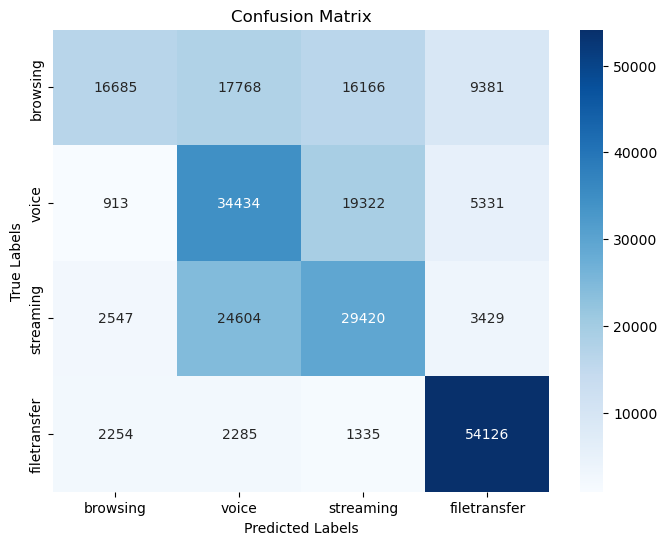

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tensorflow.keras.applications import VGG19, VGG16, MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Parámetros
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
EPOCHS = 50
FT_EPOCHS = 40

label_map = {
    0: 'browsing',
    1: 'voice',
    2: 'streaming',
    3: 'filetransfer'
}

## CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',       # Qué métrica monitorear
    patience=5,               # Cuántas épocas sin mejora esperar antes de parar
    restore_best_weights=True,  # Recupera los pesos de la mejor época
    mode='min',
    verbose=1                 # Imprime cuando detiene
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',     # Métrica a monitorear
    factor=0.5,             # Factor de reducción (lr nuevo = lr actual * factor)
    patience=3,             # Nº de épocas sin mejora antes de reducir
    min_lr=1e-6,            # Valor mínimo del learning rate
    verbose=1               # Imprime cuando reduce
)


# Cargar modelo base
base_model = MobileNetV3Large(weights="imagenet",
                   include_top=False,
                   input_shape=(IMG_SIZE[0],
                                IMG_SIZE[1], 3))
for layer in base_model.layers:
    layer.trainable = False

# Añadir capas de clasificación personalizadas
x = base_model.output
x = GlobalAveragePooling2D()(x)  
x = Dense(128, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(4, activation="softmax")(x)

# Crear modelo final
model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=Adam(learning_rate=0.0015),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Entrenar modelo
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, steps_per_epoch=800, callbacks=[early_stop, reduce_lr])

# ===============================
# Evaluación en validación
# ===============================
# Obtener etiquetas verdaderas
val_labels = []
for _, labels in val_dataset:
    val_labels.extend(tf.argmax(labels, axis=1).numpy())

# Predicciones
predictions = model.predict(val_dataset)
pred_labels = np.argmax(predictions, axis=1)

# Matriz de confusión
conf_matrix = confusion_matrix(val_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=label_map.values(), yticklabels=label_map.values())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# Fine-tuning: Descongelar últimas capas
# ===============================
for layer in base_model.layers[-8:]:  # Últimas 8 capas convolucionales
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Recompilar con menor tasa de aprendizaje
model.compile(optimizer=Adam(learning_rate=0.000005), loss="categorical_crossentropy", metrics=["accuracy"])

# Segundo entrenamiento (fine-tuning)
history_fine = model.fit(train_dataset, validation_data=val_dataset, epochs=4, steps_per_epoch=600, callbacks=[early_stop, reduce_lr])

# Evaluación final
test_loss, test_acc = model.evaluate(val_dataset)
print(f"Test Accuracy after fine-tuning: {test_acc * 100:.2f}%")

# Evaluación final con fine-tuning
val_labels_finetune = []
for _, labels in val_dataset:
    val_labels_finetune.extend(tf.argmax(labels, axis=1).numpy())

predictions_finetune = model.predict(val_dataset)
pred_labels_finetune = np.argmax(predictions_finetune, axis=1)

conf_matrix_finetune = confusion_matrix(val_labels_finetune, pred_labels_finetune)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_finetune, annot=True, fmt='d', cmap="Greens", xticklabels=label_map.values(), yticklabels=label_map.values())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Matriz de confusión despues de Fine-Tuning")
plt.show()


# Pickles

In [16]:
ruta_pickle = r'C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\pickles\MobileNetNormal'
ruta_leer_pickle = r'C:\Users\migue\Desktop\Cositis\unistuff\TFG\mio\data\pickles\MobileNetNormal\lastConFine.pkl'

In [ ]:
# GUARDAR
import pickle
import os
from sklearn.metrics import classification_report

# Define la ruta claramente
os.makedirs(ruta_pickle, exist_ok=True)

# Generar los reports de clasificación como diccionarios
reporte_inicial = classification_report(
    val_labels, pred_labels,
    target_names=list(label_map.values()),
    output_dict=True
)

reporte_finetune = classification_report(
    val_labels_finetune, pred_labels_finetune,
    target_names=list(label_map.values()),
    output_dict=True
)

# Crear un solo diccionario con toda la información
resultados_completos = {
    'historial_inicial': history.history,
    'historial_finetune': history_fine.history,
    'reporte_inicial': reporte_inicial,
    'reporte_finetune': reporte_finetune,
    'conf_matrix_inicial': conf_matrix,
    'conf_matrix_finetune': conf_matrix_finetune
}

# Guardar el diccionario en UN solo pickle
with open(os.path.join(ruta_leer_pickle), 'wb') as f:
    pickle.dump(resultados_completos, f)
